In [ ]:
# Instalação das bibliotecas necessárias
!pip install -q geoai-py geotessera geobr geopandas

import geobr
import geoai
import os


In [ ]:
# Obter o limite do DF e calcular o ponto central (centroide)
print("Obtendo dados do DF...")
df_shape = geobr.read_state(code_state="DF", year=2020)

centroid = df_shape.geometry.centroid.iloc[0]
lon, lat = centroid.x, centroid.y
print(f"Centroide do DF localizado em: Lon {lon:.4f}, Lat {lat:.4f}")

# Baixar apenas 1 tile no ponto central
output_directory = "./tessera_df_central"

print("\nBaixando tile central...")
files = geoai.tessera_download(
    lon=lon,
    lat=lat,
    year=2024,
    output_dir=output_directory,
    output_format="tiff"
)

print(f"\nDownload concluído! Arquivo gerado:")
for f in files:
    print(f"  {f}")


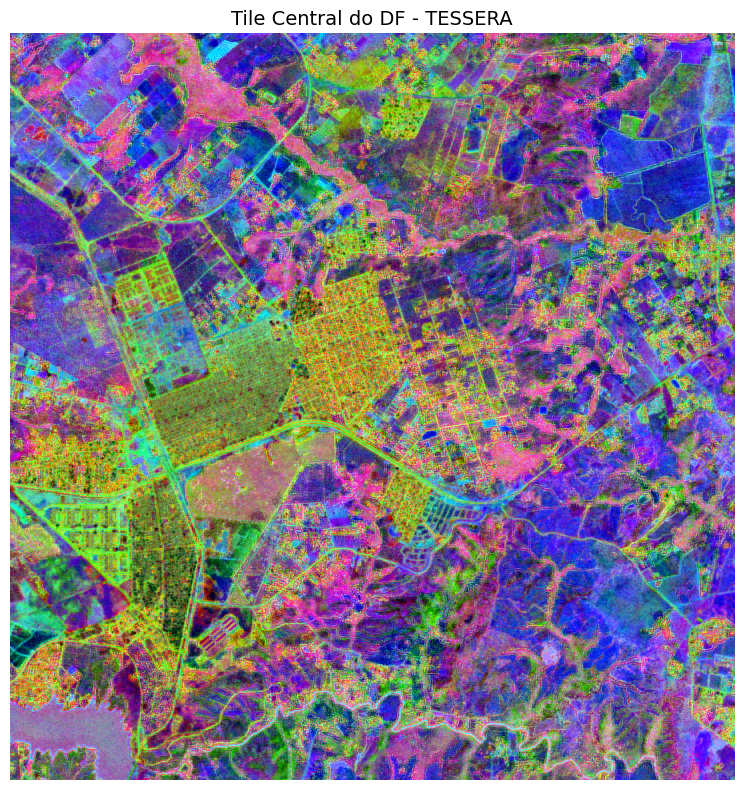

In [ ]:
# Visualização
geoai.tessera_visualize_rgb(
    '/content/tessera_df_central/global_0.1_degree_representation/2024/grid_-47.75_-15.75',
    bands=(0, 1, 2),
    title="Tile Central do DF - TESSERA"
)